
Processing D05.SI...


2025-03-23 16:52:20.350402: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/home/priya/.local/lib/python3.10/site-packages/keras/src/layers/layer.py:391: UserWarning: `build()` was called on layer 'lstm_q_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


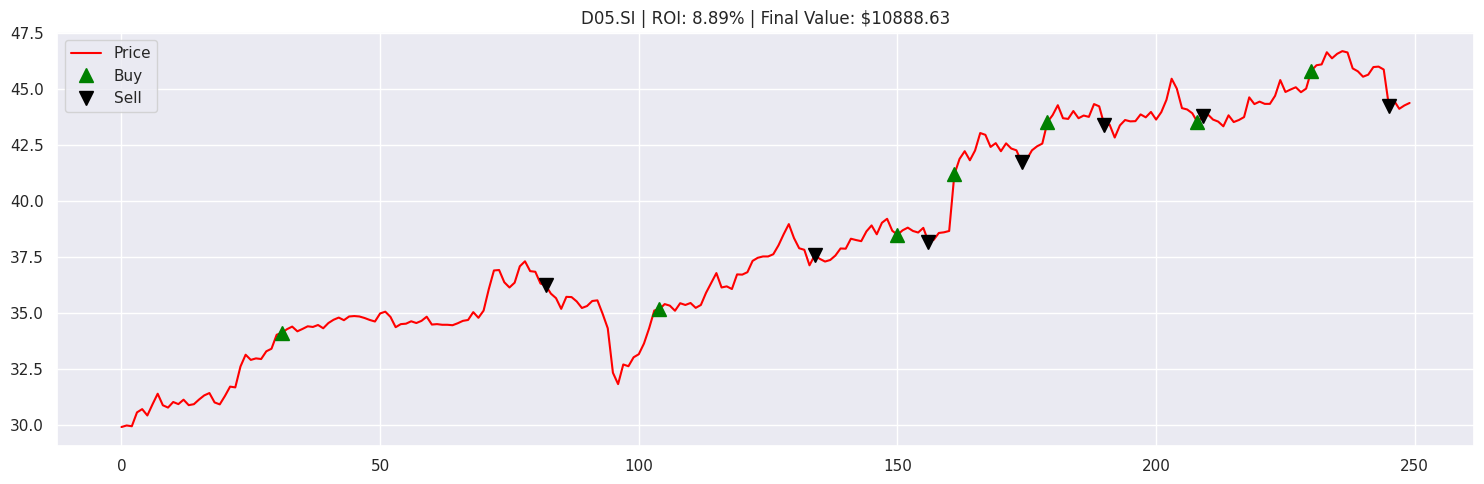


Portfolio Summary:
        Final Value       ROI
D05.SI  10888.62716  8.886272


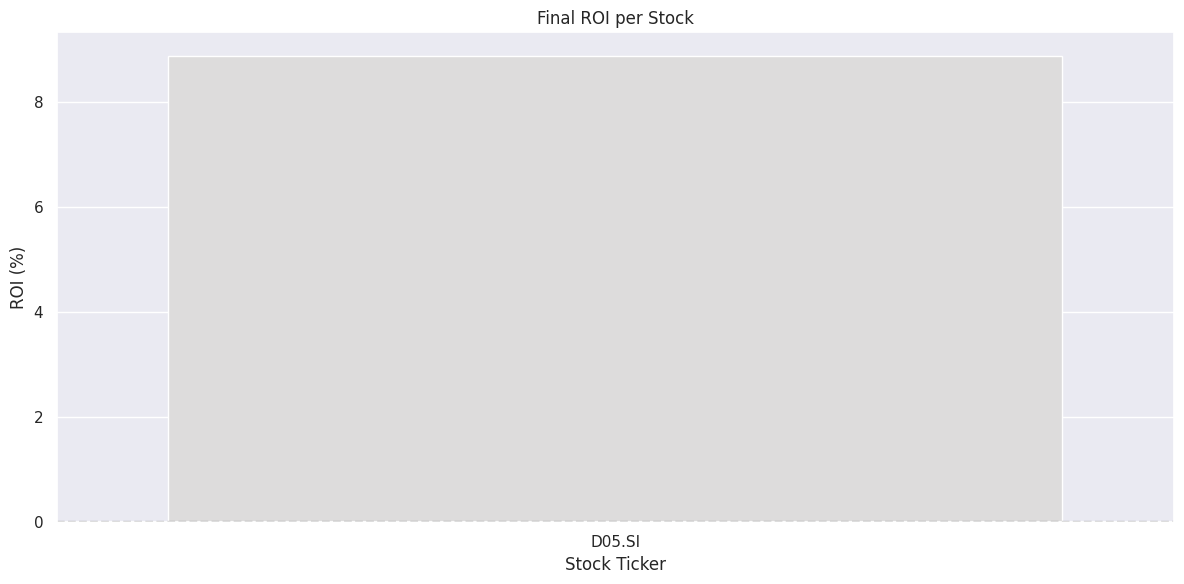

In [7]:
# ✅ Further Enhanced: Long-Term RL Strategy with Adaptive Signal Blending, Trend Confirmation & Dynamic Scaling + Curiosity-Driven Agent (TF 2.x)

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import deque
import random
import seaborn as sns

sns.set()

# Parameters
initial_money = 10000
window_size = 30
commission = 0.00125
alpha_threshold = 0.004
beta_threshold = -0.004
min_trade_profit = 0.002
volatility_buffer = 0.008
trend_confirm_window = 10
macd_weight = 0.5
rsi_weight = 0.3
trend_weight = 0.2

# Indicators

def RMA(series, period):
    rma = [series[0]]
    alpha = 1 / period
    for price in series[1:]:
        rma.append((1 - alpha) * rma[-1] + alpha * price)
    return np.array(rma)

def apply_second_order_rma(prices):
    return RMA(RMA(prices, 25), 9)

def compute_macd(prices, short=12, long=26, signal=9):
    ema_short = pd.Series(prices).ewm(span=short).mean()
    ema_long = pd.Series(prices).ewm(span=long).mean()
    macd_line = ema_short - ema_long
    signal_line = macd_line.ewm(span=signal).mean()
    return macd_line.values, signal_line.values

def compute_rsi(prices, period=14):
    delta = np.diff(prices)
    up = np.where(delta > 0, delta, 0)
    down = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(up).rolling(window=period).mean()
    avg_loss = pd.Series(down).rolling(window=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return np.concatenate([np.full(period, np.nan), rsi[period:]])

def compute_volatility(prices):
    returns = np.diff(prices) / prices[:-1]
    return np.std(returns[-10:])

def is_uptrend(prices):
    trend = np.polyfit(range(len(prices)), prices, 1)[0]
    return trend > 0

# Curiosity-Driven Q-Learning Agent

class LSTM_QNet(tf.keras.Model):
    def __init__(self, input_dim, output_dim, hidden_size=128):
        super(LSTM_QNet, self).__init__()
        self.lstm = tf.keras.layers.LSTM(hidden_size, return_sequences=True, return_state=True)
        self.dense = tf.keras.layers.Dense(output_dim)

    def call(self, x, initial_state):
        x, h, c = self.lstm(x, initial_state=initial_state)
        return self.dense(x[:, -1]), [h, c]

class CuriosityAgent:
    def __init__(self, state_dim, action_dim, hidden_size=128):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.hidden_size = hidden_size
        self.q_net = LSTM_QNet(state_dim, action_dim, hidden_size)
        self.target_net = LSTM_QNet(state_dim, action_dim, hidden_size)
        self.q_net.build(input_shape=(None, None, state_dim))
        self.target_net.set_weights(self.q_net.get_weights())
        self.optimizer = tf.keras.optimizers.Adam(0.001)
        self.memory = deque(maxlen=1000)
        self.epsilon = 1.0
        self.gamma = 0.99
        self.batch_size = 32

    def get_state(self, t, trend):
        d = t - window_size + 1
        block = trend[d:t+1] if d >= 0 else -d * [trend[0]] + trend[0:t+1]
        delta = [block[i+1] - block[i] for i in range(window_size - 1)]
        rma2 = apply_second_order_rma(block)[-1]
        macd_line, signal_line = compute_macd(block)
        rsi = compute_rsi(block)
        macd_diff = macd_line[-1] - signal_line[-1] if len(macd_line) else 0
        rsi_val = rsi[-1] if not np.isnan(rsi[-1]) else 50
        return np.array(delta + [rma2, macd_diff, rsi_val])

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_dim)
        state = state.reshape(1, 1, -1).astype(np.float32)
        logits, _ = self.q_net(state, [tf.zeros((1, self.hidden_size)), tf.zeros((1, self.hidden_size))])
        return tf.argmax(logits[0]).numpy()

    def update_target(self):
        self.target_net.set_weights(self.q_net.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train(self):
        if len(self.memory) < self.batch_size:
            return
        minibatch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*minibatch)

        states = np.array(states).reshape(self.batch_size, 1, -1).astype(np.float32)
        next_states = np.array(next_states).reshape(self.batch_size, 1, -1).astype(np.float32)
        actions = np.array(actions)
        rewards = np.array(rewards)
        dones = np.array(dones).astype(float)

        with tf.GradientTape() as tape:
            q_vals, _ = self.q_net(states, [tf.zeros((self.batch_size, self.hidden_size)), tf.zeros((self.batch_size, self.hidden_size))])
            q_targets, _ = self.target_net(next_states, [tf.zeros((self.batch_size, self.hidden_size)), tf.zeros((self.batch_size, self.hidden_size))])
            target_q = rewards + self.gamma * tf.reduce_max(q_targets, axis=1) * (1 - dones)
            main_q = tf.gather(q_vals, actions[:, None], batch_dims=1)
            loss = tf.reduce_mean(tf.square(target_q - tf.squeeze(main_q)))
        grads = tape.gradient(loss, self.q_net.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.q_net.trainable_variables))
        self.epsilon = max(0.1, self.epsilon * 0.995)

portfolio_results = {}
tickers = {"D05.SI"}

for ticker in tickers:
    print(f"\nProcessing {ticker}...")
    df = pd.read_csv(f"/home/priya/Desktop/fyp/Agents/data_store/{ticker}.csv")
    close = df['Close'].values.tolist()
    if len(close) < window_size + 20:
        print(f"Skipping {ticker} due to insufficient data.")
        continue

    agent = CuriosityAgent(window_size - 1 + 3, 3)
    portfolio = initial_money
    shares_held = 0
    states_buy, states_sell = [], []

    for t in range(window_size, len(close) - 1):
        state = agent.get_state(t, close)
        action = agent.get_action(state)
        next_state = agent.get_state(t + 1, close)

        macd_line, signal_line = compute_macd(close[max(0, t-50):t+1])
        macd_diff = macd_line[-1] - signal_line[-1] if len(macd_line) else 0
        rsi = compute_rsi(close[max(0, t-50):t+1])
        rsi_val = rsi[-1] if not np.isnan(rsi[-1]) else 50
        vol = compute_volatility(close[max(0, t-20):t+1])
        trend_score = 1 if is_uptrend(close[max(0, t-trend_confirm_window):t+1]) else -1

        weighted_signal = macd_weight * macd_diff + rsi_weight * ((50 - rsi_val) / 50) + trend_weight * trend_score
        current_price = close[t]
        expected_profit = close[t+1] * (1 - commission) - current_price * (1 + commission)

        trade_action = 0
        if weighted_signal > alpha_threshold and expected_profit > min_trade_profit * current_price and vol > volatility_buffer:
            trade_action = 1
        elif weighted_signal < beta_threshold and shares_held > 0 and vol > volatility_buffer:
            trade_action = 2

        reward = 0
        done = False

        if trade_action == 1 and portfolio >= current_price * (1 + commission):
            shares_to_buy = portfolio // (current_price * (1 + commission))
            portfolio -= shares_to_buy * current_price * (1 + commission)
            shares_held += shares_to_buy
            states_buy.append(t)
            reward = 0.01

        elif trade_action == 2 and shares_held > 0:
            portfolio += shares_held * current_price * (1 - commission)
            shares_held = 0
            states_sell.append(t)
            reward = 0.01

        if t == len(close) - 2:
            done = True

        agent.remember(state, trade_action, reward, next_state, done)
        agent.train()

    portfolio_value = portfolio + shares_held * close[-1]
    roi = (portfolio_value - initial_money) / initial_money * 100
    portfolio_results[ticker] = {"ROI": roi, "Final Value": portfolio_value}

    plt.figure(figsize=(15, 5))
    plt.plot(close, label='Price', color='red')
    plt.plot(close, '^', markersize=10, color='green', label='Buy', markevery=states_buy)
    plt.plot(close, 'v', markersize=10, color='black', label='Sell', markevery=states_sell)
    plt.title(f"{ticker} | ROI: {roi:.2f}% | Final Value: ${portfolio_value:.2f}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(portfolio_results).T
print("\nPortfolio Summary:")
print(results_df)

plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y=results_df["ROI"], hue=results_df.index, dodge=False, palette="coolwarm", legend=False)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Final ROI per Stock")
plt.ylabel("ROI (%)")
plt.xlabel("Stock Ticker")
plt.tight_layout()
plt.show()


2025-05-09 13:19:10.202517: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-09 13:19:10.241126: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746767950.285591   46915 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746767950.298449   46915 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746767950.335878   46915 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 


Processing U11.SI...


2025-05-09 13:19:15.780204: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/home/priya/.local/lib/python3.10/site-packages/keras/src/layers/layer.py:391: UserWarning: `build()` was called on layer 'lstm_q_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


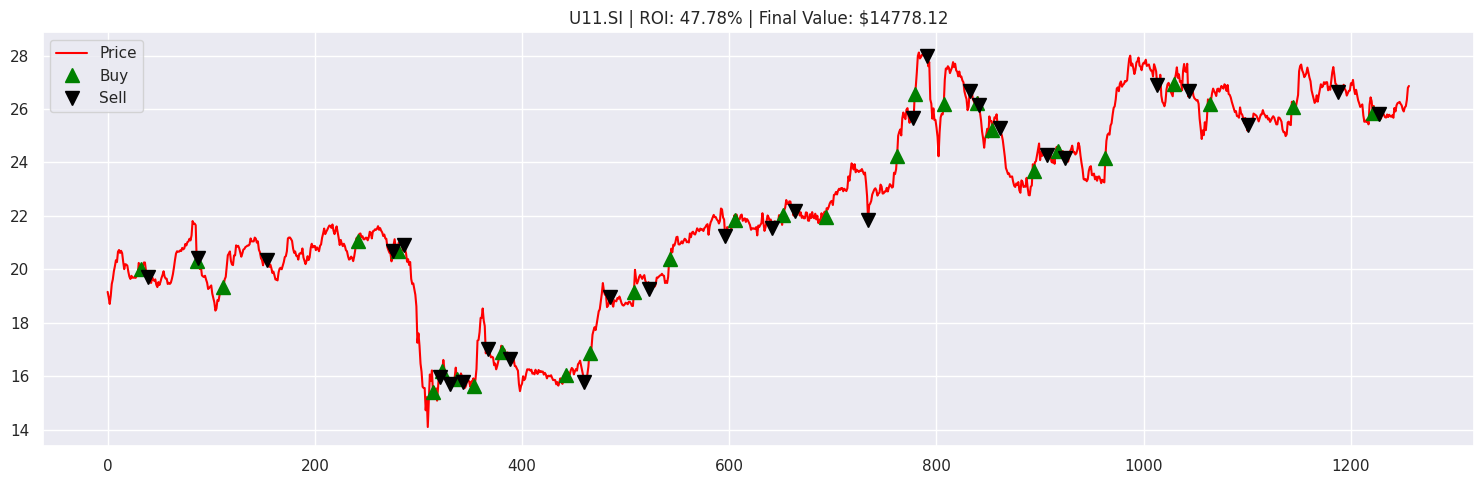


Processing C38U.SI...


/home/priya/.local/lib/python3.10/site-packages/keras/src/layers/layer.py:391: UserWarning: `build()` was called on layer 'lstm_q_net_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


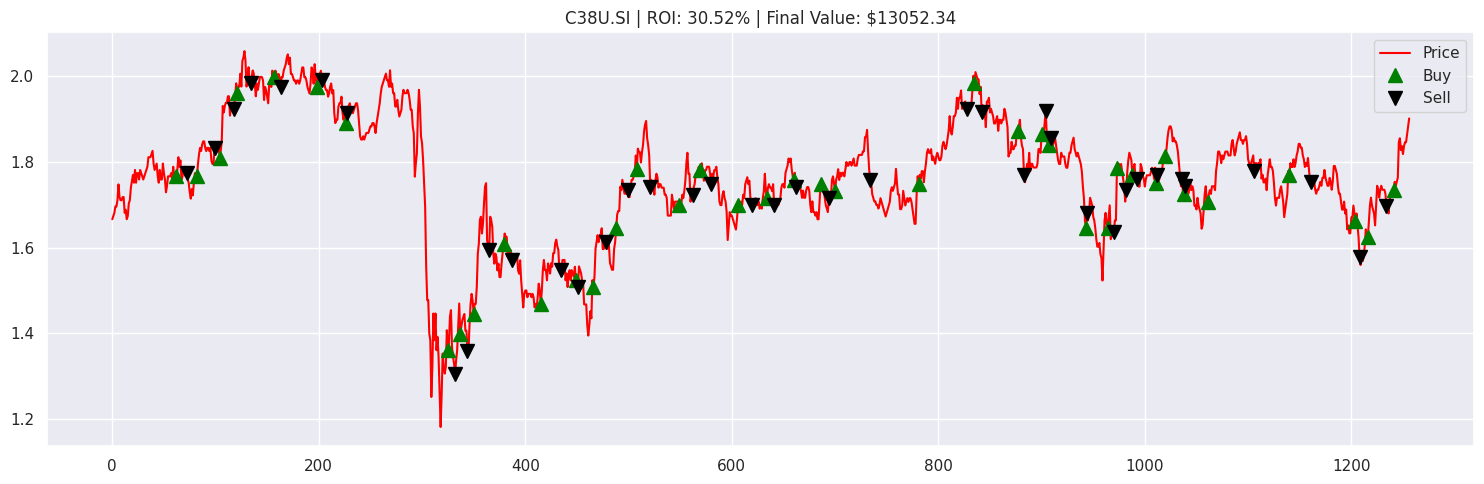


Processing Q0F.SI...


/home/priya/.local/lib/python3.10/site-packages/keras/src/layers/layer.py:391: UserWarning: `build()` was called on layer 'lstm_q_net_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


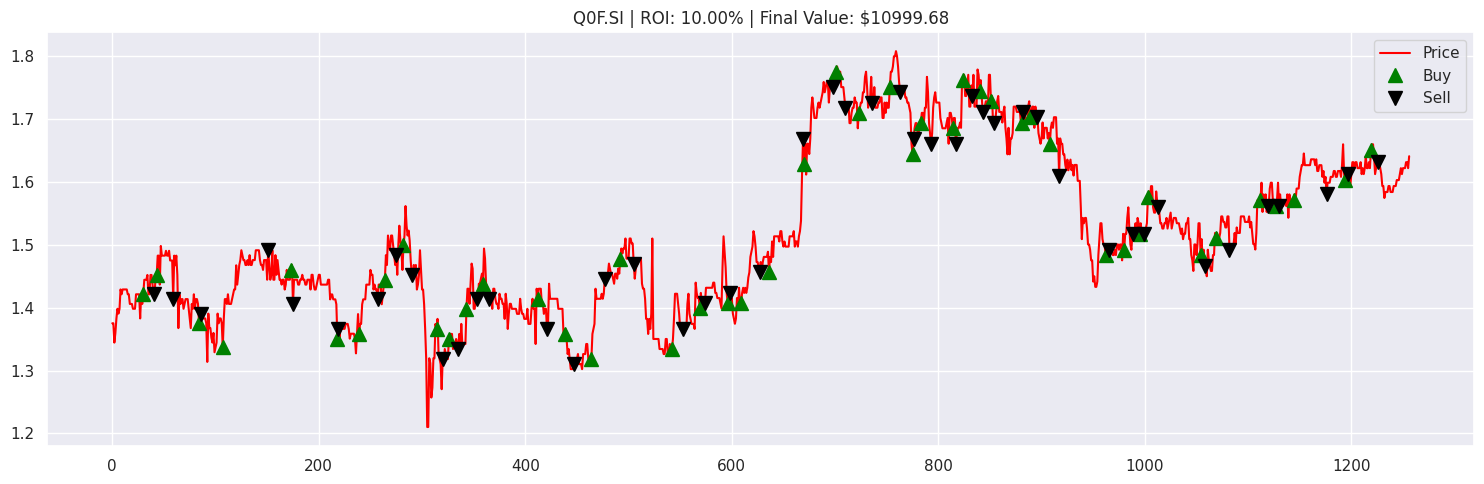


Processing S68.SI...


/home/priya/.local/lib/python3.10/site-packages/keras/src/layers/layer.py:391: UserWarning: `build()` was called on layer 'lstm_q_net_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


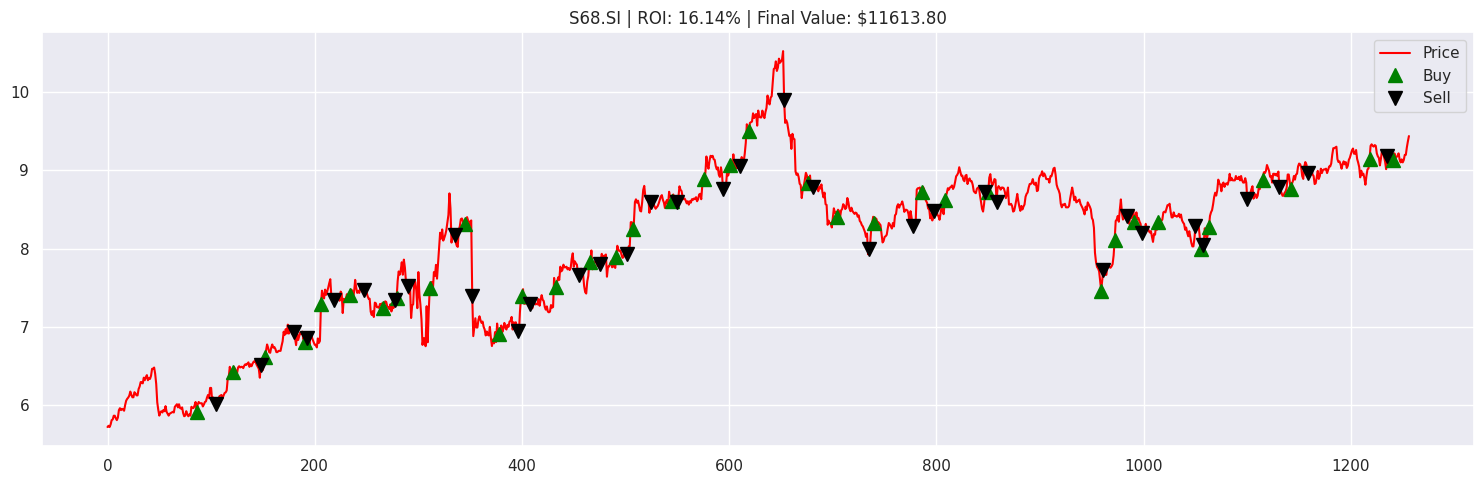


Processing S63.SI...


/home/priya/.local/lib/python3.10/site-packages/keras/src/layers/layer.py:391: UserWarning: `build()` was called on layer 'lstm_q_net_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


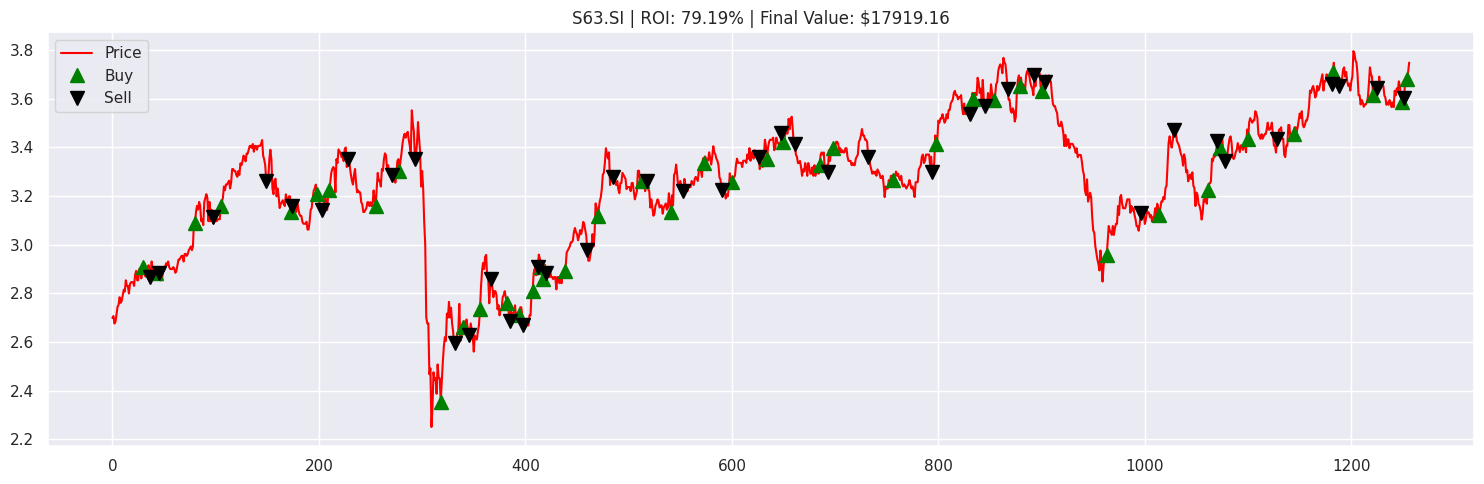


Processing AJBU.SI...


/home/priya/.local/lib/python3.10/site-packages/keras/src/layers/layer.py:391: UserWarning: `build()` was called on layer 'lstm_q_net_10', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


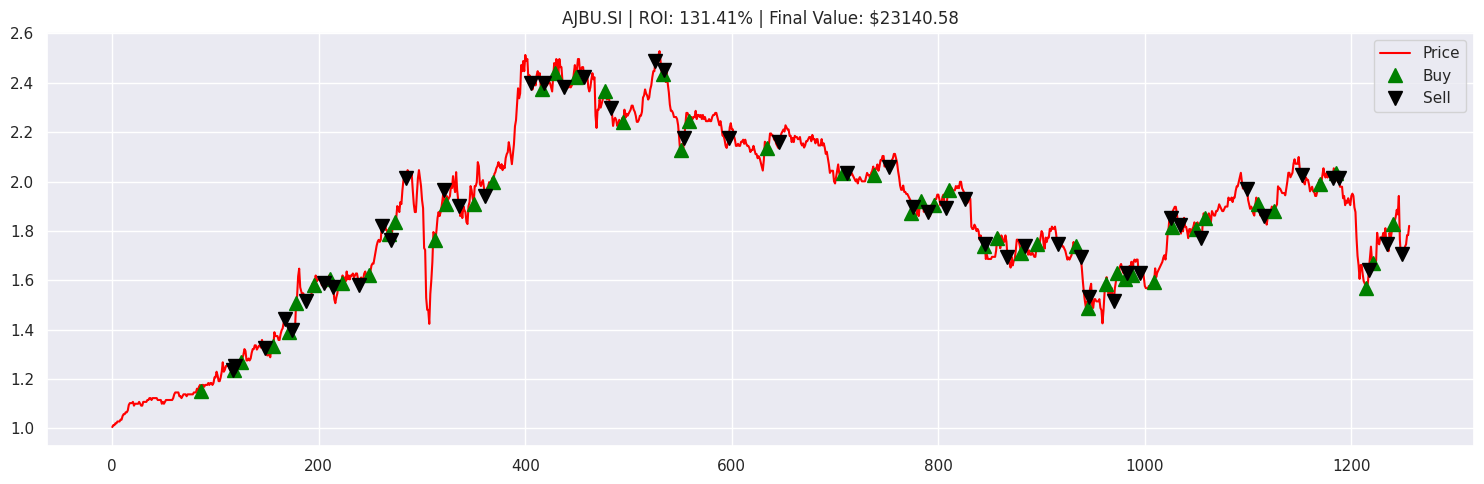


Portfolio Summary:
                ROI   Final Value
U11.SI    47.781204  14778.120437
C38U.SI   30.523354  13052.335427
Q0F.SI     9.996762  10999.676193
S68.SI    16.138012  11613.801179
S63.SI    79.191582  17919.158239
AJBU.SI  131.405824  23140.582427


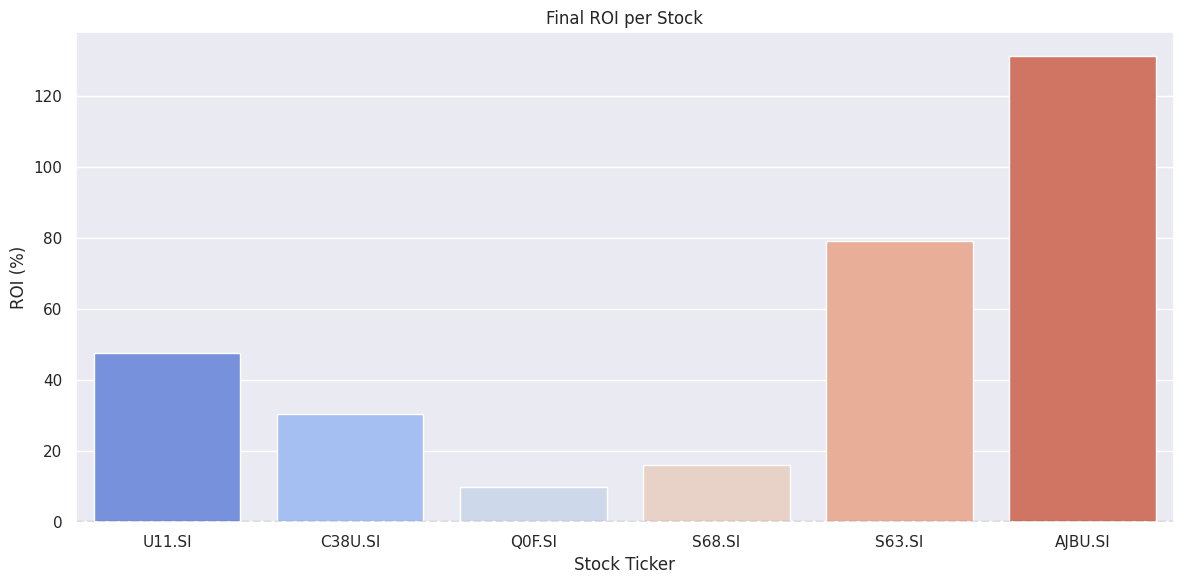

In [1]:
# ✅ Further Enhanced: Long-Term RL Strategy with Adaptive Signal Blending, Trend Confirmation & Dynamic Scaling + Curiosity-Driven Agent (TF 2.x)

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import deque
import random
import seaborn as sns

sns.set()

# Parameters
initial_money = 10000
window_size = 30
commission = 0.00125
alpha_threshold = 0.004
beta_threshold = -0.004
min_trade_profit = 0.002
volatility_buffer = 0.008
trend_confirm_window = 10
macd_weight = 0.5
rsi_weight = 0.3
trend_weight = 0.2

# Indicators

def RMA(series, period):
    rma = [series[0]]
    alpha = 1 / period
    for price in series[1:]:
        rma.append((1 - alpha) * rma[-1] + alpha * price)
    return np.array(rma)

def apply_second_order_rma(prices):
    return RMA(RMA(prices, 25), 9)

def compute_macd(prices, short=12, long=26, signal=9):
    ema_short = pd.Series(prices).ewm(span=short).mean()
    ema_long = pd.Series(prices).ewm(span=long).mean()
    macd_line = ema_short - ema_long
    signal_line = macd_line.ewm(span=signal).mean()
    return macd_line.values, signal_line.values

def compute_rsi(prices, period=14):
    delta = np.diff(prices)
    up = np.where(delta > 0, delta, 0)
    down = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(up).rolling(window=period).mean()
    avg_loss = pd.Series(down).rolling(window=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return np.concatenate([np.full(period, np.nan), rsi[period:]])

def compute_volatility(prices):
    returns = np.diff(prices) / prices[:-1]
    return np.std(returns[-10:])

def is_uptrend(prices):
    trend = np.polyfit(range(len(prices)), prices, 1)[0]
    return trend > 0

# Curiosity-Driven Q-Learning Agent

class LSTM_QNet(tf.keras.Model):
    def __init__(self, input_dim, output_dim, hidden_size=128):
        super(LSTM_QNet, self).__init__()
        self.lstm = tf.keras.layers.LSTM(hidden_size, return_sequences=True, return_state=True)
        self.dense = tf.keras.layers.Dense(output_dim)

    def call(self, x, initial_state):
        x, h, c = self.lstm(x, initial_state=initial_state)
        return self.dense(x[:, -1]), [h, c]

class CuriosityAgent:
    def __init__(self, state_dim, action_dim, hidden_size=128):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.hidden_size = hidden_size
        self.q_net = LSTM_QNet(state_dim, action_dim, hidden_size)
        self.target_net = LSTM_QNet(state_dim, action_dim, hidden_size)
        self.q_net.build(input_shape=(None, None, state_dim))
        self.target_net.set_weights(self.q_net.get_weights())
        self.optimizer = tf.keras.optimizers.Adam(0.001)
        self.memory = deque(maxlen=1000)
        self.epsilon = 1.0
        self.gamma = 0.99
        self.batch_size = 32

    def get_state(self, t, trend):
        d = t - window_size + 1
        block = trend[d:t+1] if d >= 0 else -d * [trend[0]] + trend[0:t+1]
        delta = [block[i+1] - block[i] for i in range(window_size - 1)]
        rma2 = apply_second_order_rma(block)[-1]
        macd_line, signal_line = compute_macd(block)
        rsi = compute_rsi(block)
        macd_diff = macd_line[-1] - signal_line[-1] if len(macd_line) else 0
        rsi_val = rsi[-1] if not np.isnan(rsi[-1]) else 50
        return np.array(delta + [rma2, macd_diff, rsi_val])

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_dim)
        state = state.reshape(1, 1, -1).astype(np.float32)
        logits, _ = self.q_net(state, [tf.zeros((1, self.hidden_size)), tf.zeros((1, self.hidden_size))])
        return tf.argmax(logits[0]).numpy()

    def update_target(self):
        self.target_net.set_weights(self.q_net.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train(self):
        if len(self.memory) < self.batch_size:
            return
        minibatch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*minibatch)

        states = np.array(states).reshape(self.batch_size, 1, -1).astype(np.float32)
        next_states = np.array(next_states).reshape(self.batch_size, 1, -1).astype(np.float32)
        actions = np.array(actions)
        rewards = np.array(rewards)
        dones = np.array(dones).astype(float)

        with tf.GradientTape() as tape:
            q_vals, _ = self.q_net(states, [tf.zeros((self.batch_size, self.hidden_size)), tf.zeros((self.batch_size, self.hidden_size))])
            q_targets, _ = self.target_net(next_states, [tf.zeros((self.batch_size, self.hidden_size)), tf.zeros((self.batch_size, self.hidden_size))])
            target_q = rewards + self.gamma * tf.reduce_max(q_targets, axis=1) * (1 - dones)
            main_q = tf.gather(q_vals, actions[:, None], batch_dims=1)
            loss = tf.reduce_mean(tf.square(target_q - tf.squeeze(main_q)))
        grads = tape.gradient(loss, self.q_net.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.q_net.trainable_variables))
        self.epsilon = max(0.1, self.epsilon * 0.995)

portfolio_results = {}
tickers = {
    "U11.SI": "UOB Bank",
    "C38U.SI": "CapitaLand Integrated Commercial Trust",
    "Q0F.SI": "IHH Healthcare",
    "S68.SI": "SGX",
    "S63.SI": "ST Engineering",
    "AJBU.SI": "Keppel DC REIT"
}



for ticker in tickers:
    print(f"\nProcessing {ticker}...")
    # df = pd.read_csv(f"/home/priya/Desktop/fyp/Agents/data_store/{ticker}.csv")
    # df = df.dropna(subset=["Close"])  # Drop any NaNs in Close
    df = pd.read_csv(f"/home/priya/Desktop/Multi-agent-fuzzy-neural-stock-prediction/Src/data/{ticker}/ensemble_outputs/{ticker}_ensemble_output_results.csv")
    close = df['yref_Tm0_close'].values.tolist()
    # close = df['Close'].values.tolist()
    if len(close) < window_size + 20:
        print(f"Skipping {ticker} due to insufficient data.")
        continue

    agent = CuriosityAgent(window_size - 1 + 3, 3)
    portfolio = initial_money
    shares_held = 0
    states_buy, states_sell = [], []

    for t in range(window_size, len(close) - 1):
        state = agent.get_state(t, close)
        action = agent.get_action(state)
        next_state = agent.get_state(t + 1, close)

        macd_line, signal_line = compute_macd(close[max(0, t-50):t+1])
        macd_diff = macd_line[-1] - signal_line[-1] if len(macd_line) else 0
        rsi = compute_rsi(close[max(0, t-50):t+1])
        rsi_val = rsi[-1] if not np.isnan(rsi[-1]) else 50
        vol = compute_volatility(close[max(0, t-20):t+1])
        trend_score = 1 if is_uptrend(close[max(0, t-trend_confirm_window):t+1]) else -1

        weighted_signal = macd_weight * macd_diff + rsi_weight * ((50 - rsi_val) / 50) + trend_weight * trend_score
        current_price = close[t]
        expected_profit = close[t+1] * (1 - commission) - current_price * (1 + commission)

        trade_action = 0
        if weighted_signal > alpha_threshold and expected_profit > min_trade_profit * current_price and vol > volatility_buffer:
            trade_action = 1
        elif weighted_signal < beta_threshold and shares_held > 0 and vol > volatility_buffer:
            trade_action = 2

        reward = 0
        done = False

        if trade_action == 1 and portfolio >= current_price * (1 + commission):
            shares_to_buy = portfolio // (current_price * (1 + commission))
            portfolio -= shares_to_buy * current_price * (1 + commission)
            shares_held += shares_to_buy
            states_buy.append(t)
            reward = 0.01

        elif trade_action == 2 and shares_held > 0:
            portfolio += shares_held * current_price * (1 - commission)
            shares_held = 0
            states_sell.append(t)
            reward = 0.01

        if t == len(close) - 2:
            done = True

        agent.remember(state, trade_action, reward, next_state, done)
        agent.train()

    portfolio_value = portfolio + shares_held * close[-1]
    roi = (portfolio_value - initial_money) / initial_money * 100
    portfolio_results[ticker] = {"ROI": roi, "Final Value": portfolio_value}

    plt.figure(figsize=(15, 5))
    plt.plot(close, label='Price', color='red')
    plt.plot(close, '^', markersize=10, color='green', label='Buy', markevery=states_buy)
    plt.plot(close, 'v', markersize=10, color='black', label='Sell', markevery=states_sell)
    plt.title(f"{ticker} | ROI: {roi:.2f}% | Final Value: ${portfolio_value:.2f}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(portfolio_results).T
print("\nPortfolio Summary:")
print(results_df)
results_df.to_csv('results_curiosityql.csv')

plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y=results_df["ROI"], hue=results_df.index, dodge=False, palette="coolwarm", legend=False)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Final ROI per Stock")
plt.ylabel("ROI (%)")
plt.xlabel("Stock Ticker")
plt.tight_layout()
plt.show()
